# 🫀 AI랩 Week 01 — 심전도 1D-CNN 부정맥 분류
**MedKOS / notebooks/ailab/week01_ecg_1dcnn.ipynb**

- **데이터**: MIT-BIH Arrhythmia (PhysioNet, `wfdb`로 스트리밍)
- **과제**: AAMI 5클래스(N/S/V/F/Q) 비트 분류
- **통과 기준**: macro-F1 ≥ 0.8 + 5×5 혼동행렬 + 베스트 체크포인트를 Google Drive에 저장

### 사용법
위에서부터 셀을 **순서대로** 실행. Colab 상단 메뉴 `런타임 → 런타임 유형 변경 → T4 GPU` 켜두면 빠름.

### 정직한 참고
- `SPLIT='intra'` (기본): 비트를 무작위로 나눔 → 파이프라인 학습·통과 기준(≥0.8) 달성용. 이게 1주차 목표.
- `SPLIT='inter'` (de Chazal DS1/DS2, 환자 단위 분리): 진짜 벤치마크. **훨씬 어렵고 macro-F1이 보통 0.5~0.65로 떨어짐** (특히 S 클래스). 파이프라인이 돌아간 뒤 "실전 난이도"를 체감하고 싶을 때 켜.


In [ ]:
# CELL 1 — 패키지 설치 (Colab 최초 1회, 1~2분)
!pip -q install wfdb scikit-learn
print("✅ 설치 완료")

✅ 설치 완료


In [ ]:
# CELL 2 — 설정 & 임포트
import os, numpy as np, wfdb
from collections import Counter
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# ---- 설정 (여기만 바꾸면 됨) ----
SPLIT       = "intra"   # "intra"(무작위, 통과용) | "inter"(환자단위 DS1/DS2, 어려움)
WIN_BEFORE  = 150       # R-peak 앞 샘플 수 (360Hz)
WIN_AFTER   = 150      # R-peak 뒤 샘플 수  → 총 200샘플 ≈ 0.55초
BALANCE_T   = 10000      # 클래스당 목표 표본수(학습셋만 균형화). None이면 균형화 안 함
EPOCHS      = 40
DEV_MODE    = False     # True면 레코드 몇 개만 써서 빠르게 스모크 테스트

np.random.seed(42); tf.random.set_seed(42)

# AAMI 5클래스 매핑 (MIT-BIH 심볼 → 클래스)
AAMI = {
    "N":"N","L":"N","R":"N","e":"N","j":"N",   # Normal
    "A":"S","a":"S","J":"S","S":"S",           # SVEB
    "V":"V","E":"V",                           # VEB
    "F":"F",                                   # Fusion
    "/":"Q","f":"Q","Q":"Q",                   # Unknown/paced
}
CLASSES = ["N","S","V","F","Q"]
C2I = {c:i for i,c in enumerate(CLASSES)}

# de Chazal 표준 분할 (paced 레코드 102/104/107/217 제외한 44개)
DS1 = ["101","106","108","109","112","114","115","116","118","119","122",
       "124","201","203","205","207","208","209","215","220","223","230"]
DS2 = ["100","103","105","111","113","117","121","123","200","202","210",
       "212","213","214","219","221","222","228","231","232","233","234"]
ALL = DS1 + DS2
if DEV_MODE:
    DS1, DS2 = DS1[:4], DS2[:4]; ALL = DS1 + DS2
print("설정 완료 | SPLIT =", SPLIT, "| records =", len(ALL))

설정 완료 | SPLIT = intra | records = 44


In [ ]:
# CELL 3 — MIT-BIH 로드 + 비트 분할 (PhysioNet에서 스트리밍, 몇 분 소요)
def load_beats(record_ids):
    X, y = [], []
    for rid in record_ids:
        try:
            rec = wfdb.rdrecord(rid, pn_dir="mitdb")
            ann = wfdb.rdann(rid, "atr", pn_dir="mitdb")
        except Exception as e:
            print(f"  [skip {rid}] {e}"); continue
        sig = rec.p_signal[:, 0].astype("float64")          # 채널 0 (대부분 MLII)
        sig = (sig - sig.mean()) / (sig.std() + 1e-8)        # 레코드 단위 z-정규화
        for pos, sym in zip(ann.sample, ann.symbol):
            cls = AAMI.get(sym)
            if cls is None: continue
            a, b = pos - WIN_BEFORE, pos + WIN_AFTER
            if a < 0 or b > len(sig): continue
            X.append(sig[a:b]); y.append(C2I[cls])
        print(f"  ✓ {rid}", end="  ")
    print()
    return np.array(X, dtype="float64"), np.array(y, dtype="int64")

if SPLIT == "inter":
    print("▶ DS1(train) 로드"); X_tr, y_tr = load_beats(DS1)
    print("▶ DS2(test) 로드");  X_te, y_te = load_beats(DS2)
else:
    print("▶ 전체 로드"); X_all, y_all = load_beats(ALL)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)

print("\n학습셋:", X_tr.shape, "| 테스트셋:", X_te.shape)
print("학습셋 클래스 분포:", {CLASSES[k]:v for k,v in sorted(Counter(y_tr).items())})

▶ 전체 로드
  ✓ 101    ✓ 106    ✓ 108    ✓ 109    ✓ 112    ✓ 114    ✓ 115    ✓ 116    ✓ 118    ✓ 119    ✓ 122    ✓ 124    ✓ 201    ✓ 203    ✓ 205    ✓ 207    ✓ 208    ✓ 209    ✓ 215    ✓ 220    ✓ 223    ✓ 230    ✓ 100    ✓ 103    ✓ 105    ✓ 111    ✓ 113    ✓ 117    ✓ 121    ✓ 123    ✓ 200    ✓ 202    ✓ 210    ✓ 212    ✓ 213    ✓ 214    ✓ 219    ✓ 221    ✓ 222    ✓ 228    ✓ 231    ✓ 232    ✓ 233    ✓ 234  

학습셋: (80550, 300) | 테스트셋: (20138, 300)
학습셋 클래스 분포: {'N': 72065, 'S': 2225, 'V': 5606, 'F': 642, 'Q': 12}


In [ ]:
# CELL 4 — 학습셋 클래스 균형화 (테스트셋은 원래 분포 유지)
def balance(X, y, target):
    Xs, ys = [], []
    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        pick = np.random.choice(idx, target, replace=len(idx) < target)
        Xs.append(X[pick]); ys.append(y[pick])
    X2, y2 = np.concatenate(Xs), np.concatenate(ys)
    p = np.random.permutation(len(y2))
    return X2[p], y2[p]

if BALANCE_T:
    X_tr, y_tr = balance(X_tr, y_tr, BALANCE_T)
    print("균형화 후 학습셋:", X_tr.shape,
          {CLASSES[k]:v for k,v in sorted(Counter(y_tr).items())})

# (n, len) → (n, len, 1)
if X_tr.ndim == 2:
    X_tr = X_tr[..., None]
    print(f"▶ 학습셋 1D-CNN 차원 확장 완료: {X_tr.shape}")
else:
    print(f"⚠️ 이미 차원이 확장되어 있어 스킵합니다. 현재 차원: {X_tr.shape}")

if X_te.ndim == 2:
    X_te = X_te[..., None]
    print(f"▶ 테스트셋 1D-CNN 차원 확장 완료: {X_te.shape}")
else:
    print(f"⚠️ 이미 차원이 확장되어 있어 스킵합니다. 현재 차원: {X_te.shape}")

INPUT_LEN = X_tr.shape[1]

# (이후 class_weight 계산 코드는 그대로 유지)
cw = compute_class_weight("balanced", classes=np.arange(5), y=y_tr)
class_weight = {i:float(w) for i,w in enumerate(cw)}
print("class_weight:", {CLASSES[i]:round(w,2) for i,w in class_weight.items()})

cw = compute_class_weight("balanced", classes=np.arange(5), y=y_tr)
class_weight = {i:float(w) for i,w in enumerate(cw)}
print("class_weight:", {CLASSES[i]:round(w,2) for i,w in class_weight.items()})

균형화 후 학습셋: (50000, 300) {'N': 10000, 'S': 10000, 'V': 10000, 'F': 10000, 'Q': 10000}
▶ 학습셋 1D-CNN 차원 확장 완료: (50000, 300, 1)
▶ 테스트셋 1D-CNN 차원 확장 완료: (20138, 300, 1)
class_weight: {'N': 1.0, 'S': 1.0, 'V': 1.0, 'F': 1.0, 'Q': 1.0}
class_weight: {'N': 1.0, 'S': 1.0, 'V': 1.0, 'F': 1.0, 'Q': 1.0}


In [ ]:
# CELL 5 — 1D-CNN 모델
def build_model(input_len, n_classes=5):
    m = models.Sequential([
        layers.Input((input_len, 1)),
        layers.Conv1D(32, 13, padding="same", activation="relu"),
        layers.BatchNormalization(), layers.MaxPooling1D(2),
        layers.Conv1D(64, 11, padding="same", activation="relu"),
        layers.BatchNormalization(), layers.MaxPooling1D(2),
        layers.Conv1D(128, 9, padding="same", activation="relu"),
        layers.BatchNormalization(), layers.MaxPooling1D(2),
        layers.Conv1D(256, 7, padding="same", activation="relu"),
        layers.BatchNormalization(), layers.MaxPooling1D(2),
        layers.Conv1D(512, 5, padding="same", activation="relu"),
        layers.BatchNormalization(), layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation="relu"), layers.Dropout(0.2),
        layers.Dense(n_classes, activation="softmax"),
    ])
    m.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
    return m

model = build_model(INPUT_LEN)
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_41 (Conv1D)              │ (None, 300, 32)        │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 300, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_33 (MaxPooling1D) │ (None, 150, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_42 (Conv1D)              │ (None, 150, 64)        │        22,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 150, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_34 (MaxPooling1D) │ (None, 75, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_43 (Conv1D)              │ (None, 75, 128)        │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 75, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_35 (MaxPooling1D) │ (None, 37, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_44 (Conv1D)              │ (None, 37, 256)        │       229,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 37, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_36 (MaxPooling1D) │ (None, 18, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_45 (Conv1D)              │ (None, 18, 512)        │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 18, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_8      │ (None, 512)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,019,525 (3.89 MB)

 Trainable params: 1,017,541 (3.88 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
# CELL 6 — 학습 (베스트 가중치를 val_accuracy 기준으로 저장)
CKPT = "/content/week01_best.keras"
cbs = [
    callbacks.ModelCheckpoint(CKPT, monitor="val_accuracy",
                              save_best_only=True, verbose=0),
    callbacks.EarlyStopping(monitor="val_accuracy", patience=6,
                            restore_best_weights=True),
]
hist = model.fit(X_tr, y_tr, validation_split=0.3,
                 epochs=EPOCHS, batch_size=128,
                 class_weight=class_weight, callbacks=cbs, verbose=1)

Epoch 1/40
274/274 ━━━━━━━━━━━━━━━━━━━━ 33s 38ms/step - accuracy: 0.9131 - loss: 0.2548 - val_accuracy: 0.7164 - val_loss: 0.7135
Epoch 2/40
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9664 - loss: 0.1051 - val_accuracy: 0.9561 - val_loss: 0.1199
Epoch 3/40
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9763 - loss: 0.0689 - val_accuracy: 0.9691 - val_loss: 0.0889
Epoch 4/40
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9836 - loss: 0.0503 - val_accuracy: 0.9761 - val_loss: 0.0810
Epoch 5/40
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.9880 - loss: 0.0382 - val_accuracy: 0.9773 - val_loss: 0.0703
Epoch 6/40
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9898 - loss: 0.0315 - val_accuracy: 0.9818 - val_loss: 0.0598
Epoch 7/40
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9910 - loss: 0.0289 - val_accuracy: 0.9864 - val_loss: 0.0474
Epoch 8/40
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9928 - loss: 0.0233 - val_acc

  macro-F1 = 0.8273   →   ✅ PASS (≥0.8)
              precision    recall  f1-score   support

           N      0.998     0.990     0.994     18017
           S      0.817     0.955     0.881       556
           V      0.969     0.987     0.978      1402
           F      0.813     0.869     0.840       160
           Q      0.333     0.667     0.444         3

    accuracy                          0.988     20138
   macro avg      0.786     0.894     0.827     20138
weighted avg      0.989     0.988     0.988     20138



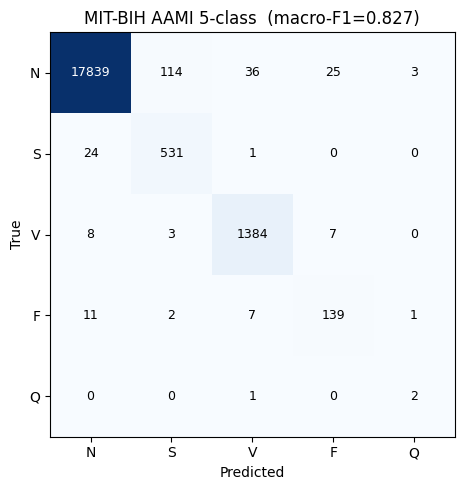

In [ ]:
# CELL 7 — 평가: macro-F1 + 혼동행렬 + 통과 판정
y_pred = model.predict(X_te, verbose=0).argmax(1)
macro = f1_score(y_te, y_pred, average="macro")

print("="*46)
print(f"  macro-F1 = {macro:.4f}   →   {'✅ PASS (≥0.8)' if macro>=0.8 else '❌ 미달 (<0.8)'}")
print("="*46)
print(classification_report(y_te, y_pred, target_names=CLASSES, digits=3))

cm = confusion_matrix(y_te, y_pred)
fig, ax = plt.subplots(figsize=(5.5,5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(5)); ax.set_xticklabels(CLASSES)
ax.set_yticks(range(5)); ax.set_yticklabels(CLASSES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"MIT-BIH AAMI 5-class  (macro-F1={macro:.3f})")
for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i,j], ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=9)
plt.tight_layout(); plt.savefig("/content/week01_confusion.png", dpi=130); plt.show()

In [ ]:
# CELL 8 — Google Drive에 체크포인트 + 결과 저장
from google.colab import drive
import shutil, json, datetime
drive.mount("/content/drive")

OUT = "/content/drive/MyDrive/MedKOS/ailab/week01"
os.makedirs(OUT, exist_ok=True)
shutil.copy(CKPT, f"{OUT}/week01_best.keras")
shutil.copy("/content/week01_confusion.png", f"{OUT}/week01_confusion.png")

result = {
    "week": 1, "task": "ECG 1D-CNN (MIT-BIH AAMI 5-class)",
    "split": SPLIT, "macro_f1": round(float(macro), 4),
    "passed": bool(macro >= 0.8),
    "date": datetime.date.today().isoformat(),
}
with open(f"{OUT}/result.json", "w") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)
print("✅ Drive 저장 완료:", OUT)
print(json.dumps(result, ensure_ascii=False, indent=2))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive 저장 완료: /content/drive/MyDrive/MedKOS/ailab/week01
{
  "week": 1,
  "task": "ECG 1D-CNN (MIT-BIH AAMI 5-class)",
  "split": "intra",
  "macro_f1": 0.8273,
  "passed": true,
  "date": "2026-07-12"
}


## MedKOS에 기록하기 (마지막 단계)
`result.json`의 내용을 MedKOS 레포에 결과 마크다운 한 장으로 커밋하면 1주차 완료 근거가 됨. 예:

```markdown
---
type: ailab_log
week: 1
task: ECG 1D-CNN (MIT-BIH AAMI 5-class)
split: intra
macro_f1: 0.86
passed: true
date: 2026-07-08
notebook: notebooks/ailab/week01_ecg_1dcnn.ipynb
checkpoint: drive:MedKOS/ailab/week01/week01_best.keras
---
1주차 완료. intra split에서 macro-F1 0.86. 다음: inter split(DS1/DS2)로 실전 난이도 체감.
```

노트북 자체는 무거우니 git엔 이 로그 md만 커밋하고, `.keras`/`.png`는 Drive에 두는 걸 추천.